# NLP Assignment 02: Word2Vec & Topic Modeling
## Student: Taha Fayyaz

This notebook completes all required tasks of the assignment:

1. Load and preprocess an open-source dataset
2. Train **CBOW** and **Skip-Gram** Word2Vec models
3. Compare similar words from both models
4. Visualize embeddings in 2D
5. Perform **LDA topic modeling**
6. Reflect on similarity types and topic fit

> Recommended environment: Python 3.10+ with `gensim`, `nltk`, `scikit-learn`, `matplotlib`, `pandas`, and `wordcloud`

In [1]:

# Uncomment this cell only if the required libraries are not installed.
!pip install gensim nltk scikit-learn matplotlib pandas wordcloud


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 16.3 MB/s eta 0:00:00


In [2]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [3]:

import re
import random
from collections import Counter

import gensim.downloader as api
from gensim.models import Word2Vec, LdaModel
from gensim.corpora import Dictionary

import nltk
from nltk.corpus import stopwords
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import pandas as pd

from wordcloud import WordCloud

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

random.seed(42)


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


# Step 1: Load and Preprocess Dataset

This assignment uses the **Text8** dataset from Gensim.  
Text8 is a clean, open-source corpus derived from Wikipedia text and is commonly used for Word2Vec experiments.

### Preprocessing performed here:
- convert text to lowercase
- remove punctuation and non-alphabetic tokens
- remove stopwords
- tokenize the text

In [4]:

# Load Text8 from Gensim
dataset = api.load('text8')   # iterable of tokenized sentences

# Convert to list so we can reuse it multiple times
raw_sentences = list(dataset)

print(f"Number of original sentences: {len(raw_sentences)}")
print("Sample sentence (first 20 tokens):")
print(raw_sentences[0][:20])

def preprocess_sentences(sentences, stop_words):
    processed = []
    for sent in sentences:
        cleaned_tokens = []
        for token in sent:
            token = token.lower().strip()
            token = re.sub(r'[^a-z]', '', token)   # keep alphabets only
            if token and token not in stop_words:
                cleaned_tokens.append(token)
        if cleaned_tokens:
            processed.append(cleaned_tokens)
    return processed

sentences = preprocess_sentences(raw_sentences, stop_words)

all_tokens = [token for sent in sentences for token in sent]
vocab = sorted(set(all_tokens))

print("\nAfter preprocessing:")
print(f"Total number of tokens: {len(all_tokens):,}")
print(f"Vocabulary size: {len(vocab):,}")

assert len(vocab) >= 1000, "Vocabulary size should be at least 1000."


[==================================================] 100.0% 31.6/31.6MB downloaded
Number of original sentences: 1701
Sample sentence (first 20 tokens):
['anarchism', 'originated', 'as', 'a', 'term', 'of', 'abuse', 'first', 'used', 'against', 'early', 'working', 'class', 'radicals', 'including', 'the', 'diggers', 'of', 'the', 'english']

After preprocessing:
Total number of tokens: 10,890,638
Vocabulary size: 253,702


# Step 2: Train Word2Vec Models (CBOW and Skip-Gram)

The following parameters were used as required by the assignment:
- `vector_size=50`
- `window=5`
- `min_count=2`
- `epochs=10`

Model settings:
- **CBOW** → `sg=0`
- **Skip-Gram** → `sg=1`

Both models were trained on the same preprocessed corpus so that their results could be compared fairly.

In [5]:

common_params = {
    "vector_size": 50,
    "window": 5,
    "min_count": 2,
    "workers": 4,
    "epochs": 10,
    "seed": 42
}

cbow_model = Word2Vec(
    sentences=sentences,
    sg=0,   # CBOW
    **common_params
)

skipgram_model = Word2Vec(
    sentences=sentences,
    sg=1,   # Skip-Gram
    **common_params
)

print("CBOW model trained.")
print("Skip-Gram model trained.")

cbow_model.save("word2vec_cbow_taha_fayyaz.model")
skipgram_model.save("word2vec_skipgram_taha_fayyaz.model")

print("Models saved successfully.")


CBOW model trained.
Skip-Gram model trained.
Models saved successfully.


In [6]:

# Required: show top 5 similar words for 3 chosen words
candidate_words = ['science', 'human', 'data']

# Fallback: if any chosen word is missing from vocabulary, replace it with common in-vocab words
fallback_words = ["science", "human", "data", "computer", "world", "music", "history", "system", "research"]

final_words = []
for w in candidate_words:
    if w in cbow_model.wv and w in skipgram_model.wv:
        final_words.append(w)

for fw in fallback_words:
    if len(final_words) == 3:
        break
    if fw not in final_words and fw in cbow_model.wv and fw in skipgram_model.wv:
        final_words.append(fw)

print("Words selected for similarity comparison:", final_words)

for word in final_words:
    print("\n" + "="*70)
    print(f"WORD: {word}")

    print("\nCBOW - Top 5 similar words:")
    for similar_word, score in cbow_model.wv.most_similar(word, topn=5):
        print(f"  {similar_word:15s}  {score:.4f}")

    print("\nSkip-Gram - Top 5 similar words:")
    for similar_word, score in skipgram_model.wv.most_similar(word, topn=5):
        print(f"  {similar_word:15s}  {score:.4f}")


Words selected for similarity comparison: ['science', 'human', 'data']

WORD: science

CBOW - Top 5 similar words:
  astrobiology     0.6597
  interdisciplinary  0.6467
  sciences         0.6446
  ecosophy         0.6424
  psychology       0.6412

Skip-Gram - Top 5 similar words:
  fiction          0.8015
  nanoscience      0.8009
  populariser      0.7955
  multidisciplinary  0.7929
  bioethics        0.7833

WORD: human

CBOW - Top 5 similar words:
  animal           0.7475
  sentient         0.7042
  humans           0.6964
  reproductive     0.6669
  animals          0.6567

Skip-Gram - Top 5 similar words:
  animal           0.8278
  nonhuman         0.8106
  humans           0.7825
  instinctual      0.7769
  epms             0.7765

WORD: data

CBOW - Top 5 similar words:
  parameters       0.7319
  storing          0.7300
  dbms             0.7195
  dns              0.7101
  indexes          0.7099

Skip-Gram - Top 5 similar words:
  terabytes        0.8525
  gedcom           0

# Step 3: Embedding Visualization

In this step, the **top 50 most frequent words** were selected from the vocabulary, and their 50-dimensional embeddings were reduced to **2D** for visualization.

The assignment allows the use of **PCA** or **t-SNE**. In this notebook, **PCA** was used.

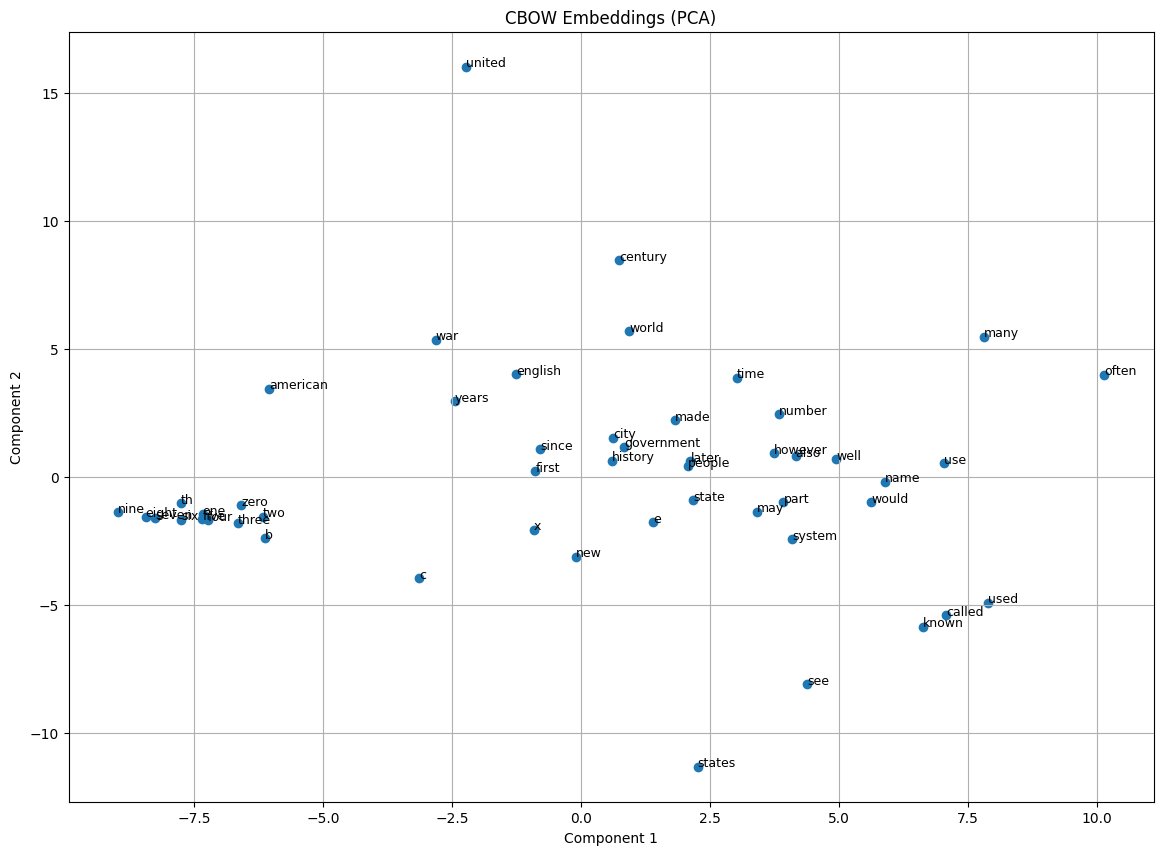

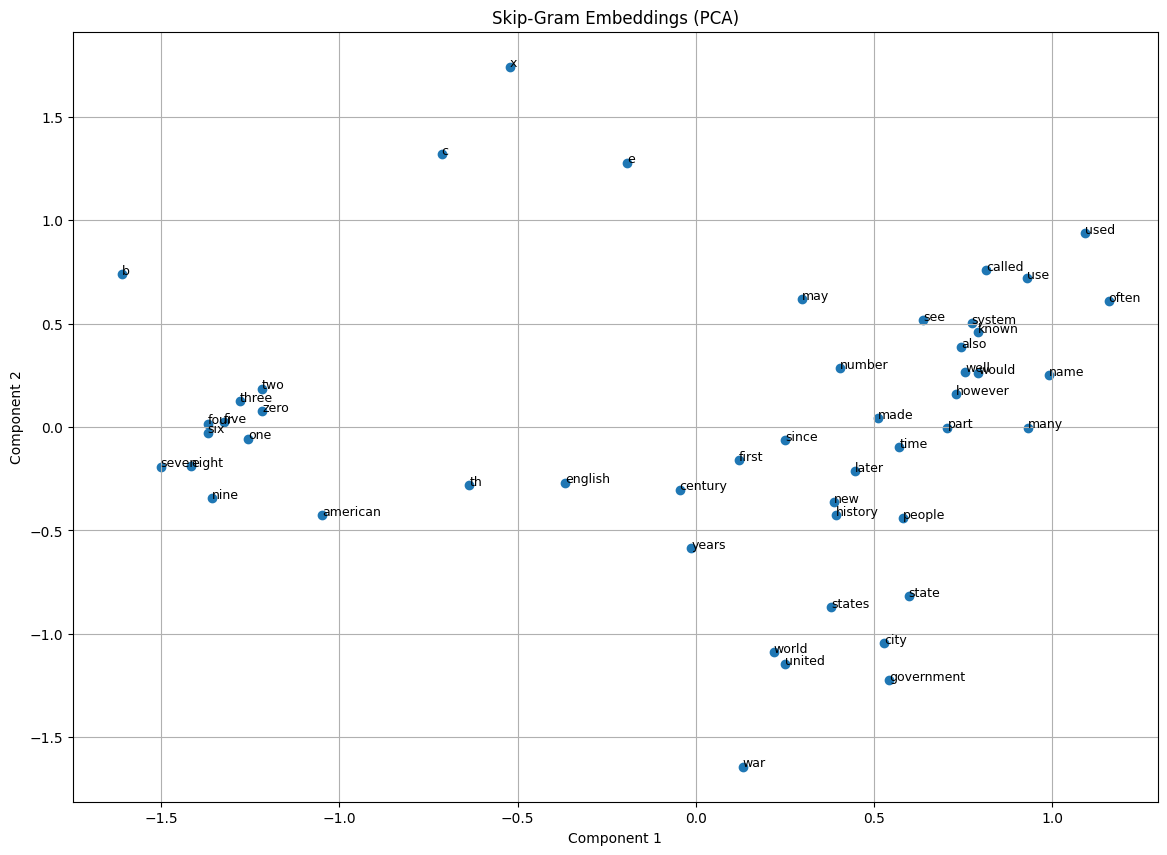

In [8]:
# Step 3: Embedding Visualization

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Top 50 frequent words directly from model vocabulary
vocab_with_counts = []
for word in cbow_model.wv.index_to_key:
    count = cbow_model.wv.get_vecattr(word, "count")
    vocab_with_counts.append((word, count))

top_50_words = [word for word, count in sorted(vocab_with_counts, key=lambda x: x[1], reverse=True)[:50]]

cbow_vectors = [cbow_model.wv[word] for word in top_50_words if word in cbow_model.wv]
skip_vectors = [skipgram_model.wv[word] for word in top_50_words if word in skipgram_model.wv]

# keep same word list in sync
top_50_words = [word for word in top_50_words if word in cbow_model.wv and word in skipgram_model.wv]

cbow_vectors = [cbow_model.wv[word] for word in top_50_words]
skip_vectors = [skipgram_model.wv[word] for word in top_50_words]

pca = PCA(n_components=2, random_state=42)
cbow_2d = pca.fit_transform(cbow_vectors)
skip_2d = pca.fit_transform(skip_vectors)

def plot_embeddings(words, coords, title):
    plt.figure(figsize=(14, 10))
    plt.scatter(coords[:, 0], coords[:, 1])
    for i, word in enumerate(words):
        plt.annotate(word, (coords[i, 0], coords[i, 1]), fontsize=9)
    plt.title(title)
    plt.xlabel("Component 1")
    plt.ylabel("Component 2")
    plt.grid(True)
    plt.show()

plot_embeddings(top_50_words, cbow_2d, "CBOW Embeddings (PCA)")
plot_embeddings(top_50_words, skip_2d, "Skip-Gram Embeddings (PCA)")

### 3-line Comparison of Clustering

1. **CBOW** generally forms smoother and more compact clusters because it learns by predicting a target word from its surrounding context.  
2. **Skip-Gram** often captures more detailed semantic relationships, especially for less frequent words, so its clusters may appear more spread out but semantically richer.  
3. In practice, CBOW is usually faster and more stable, while Skip-Gram may preserve finer semantic structure.

# Step 4: Topic Modeling with LDA

In this step, a dictionary and Bag-of-Words corpus were created from the preprocessed text, and **5 topics** were extracted using Gensim’s `LdaModel`.

The top keywords of each topic were then visualized using bar charts and word clouds to help interpret the main themes present in the corpus.

In [11]:
# Step 4: Topic Modeling with LDA

from gensim.corpora import Dictionary
from gensim.models import LdaModel
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Smaller subset for fast Colab execution
lda_sentences = sentences[:1000]

# Create dictionary and BoW corpus
dictionary = Dictionary(lda_sentences)
dictionary.filter_extremes(no_below=3, no_above=0.4)

bow_corpus = [dictionary.doc2bow(sent) for sent in lda_sentences]

# Train LDA model with 5 topics
lda_model = LdaModel(
    corpus=bow_corpus,
    id2word=dictionary,
    num_topics=5,
    random_state=42,
    passes=2,
    iterations=50,
    alpha='auto'
)

print("Top words in each topic:\n")
topic_data = []

for topic_id in range(5):
    terms = lda_model.show_topic(topic_id, topn=10)
    print(f"Topic {topic_id}:")
    print(terms)
    print()
    topic_data.append((topic_id, terms))

Top words in each topic:

Topic 0:
[('software', np.float32(0.0016349864)), ('apple', np.float32(0.0007747911)), ('album', np.float32(0.0006708995)), ('species', np.float32(0.00063951546)), ('films', np.float32(0.00062595773)), ('frac', np.float32(0.0006204897)), ('boston', np.float32(0.00061937683)), ('league', np.float32(0.00061660877)), ('players', np.float32(0.00061134895)), ('jewish', np.float32(0.00060418615))]

Topic 1:
[('chinese', np.float32(0.0011114137)), ('season', np.float32(0.0010320346)), ('league', np.float32(0.0008264779)), ('software', np.float32(0.00082172896)), ('economy', np.float32(0.000772168)), ('aircraft', np.float32(0.0007598893)), ('alexander', np.float32(0.0007146055)), ('islands', np.float32(0.0006915846)), ('football', np.float32(0.00069121784)), ('christmas', np.float32(0.000685263))]

Topic 2:
[('islands', np.float32(0.0015876642)), ('emperor', np.float32(0.0014322886)), ('soviet', np.float32(0.0011251746)), ('economy', np.float32(0.0010482623)), ('films

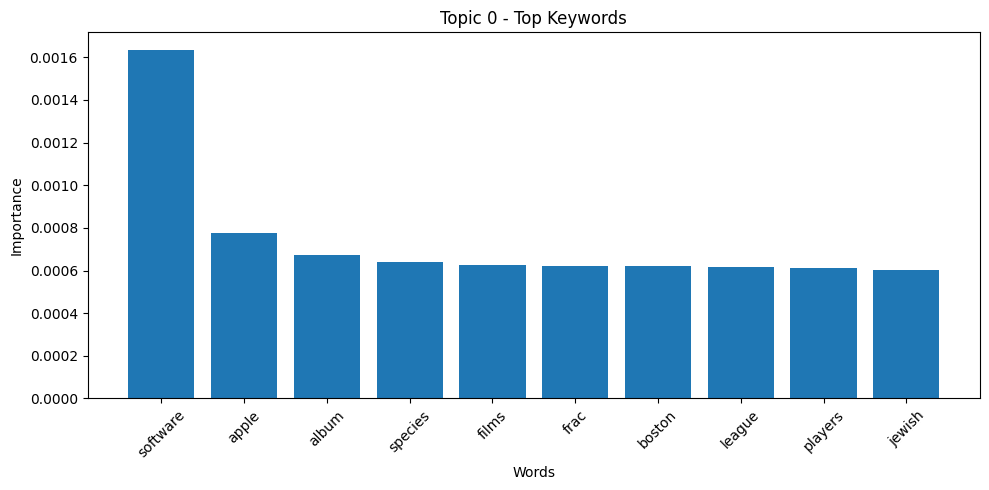

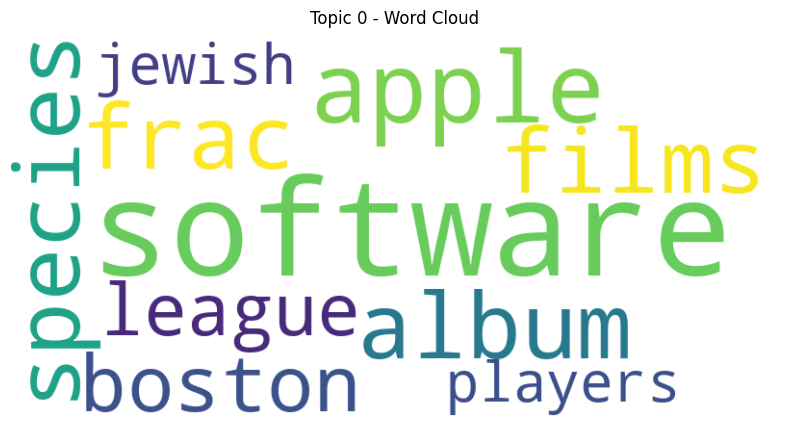

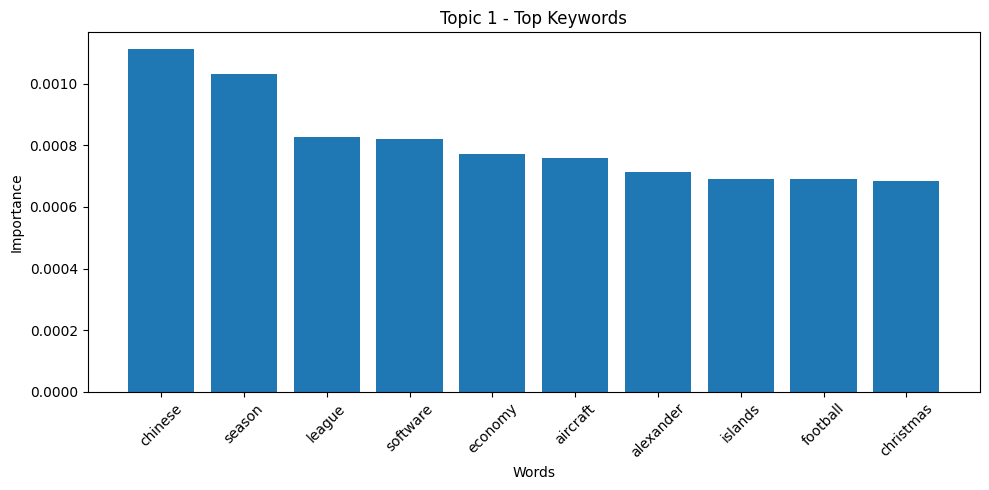

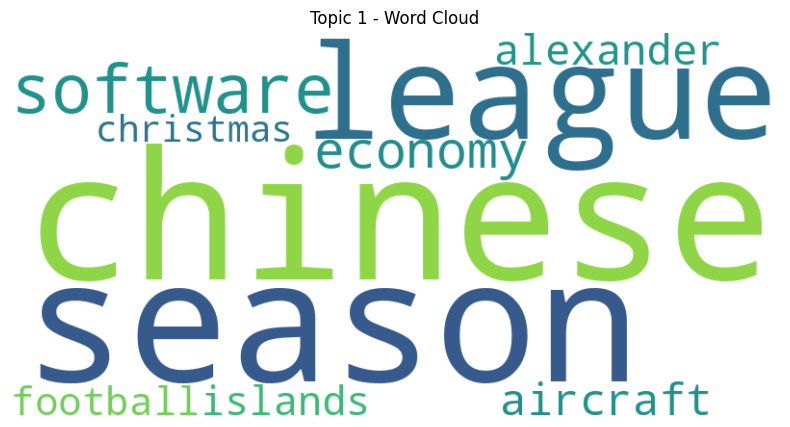

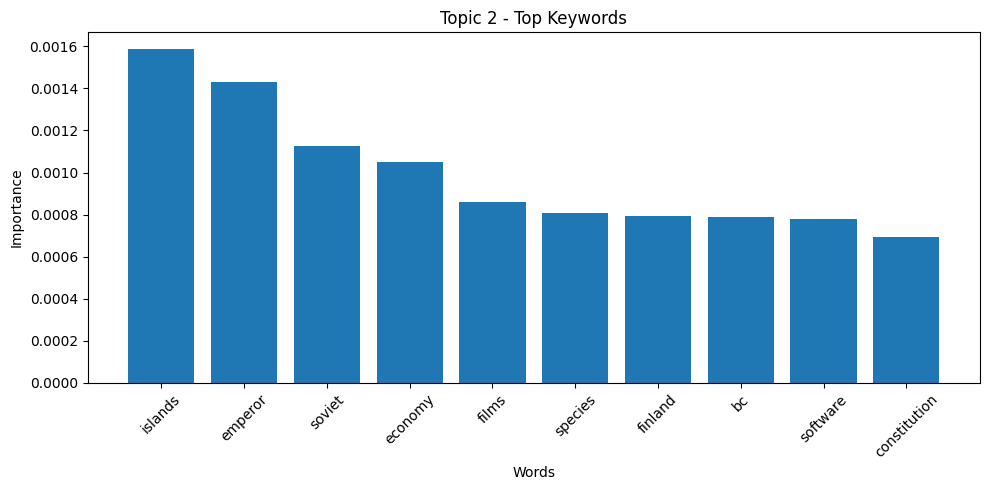

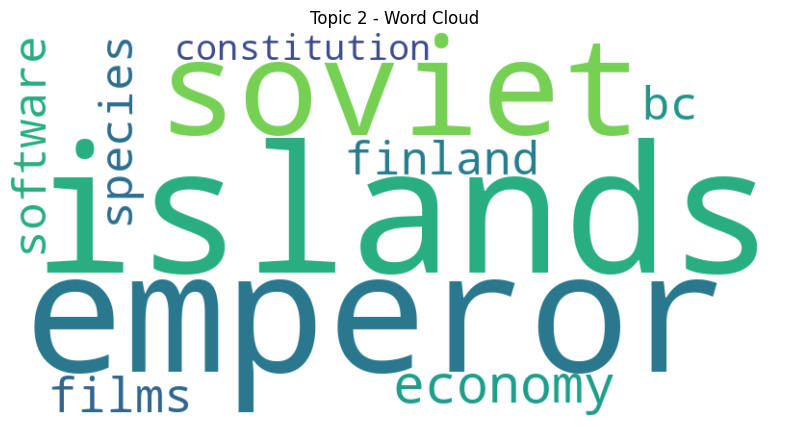

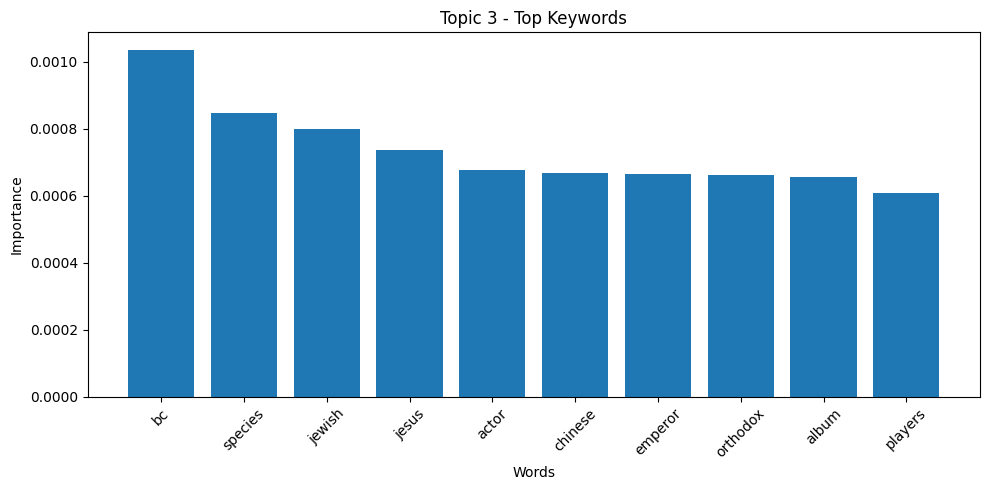

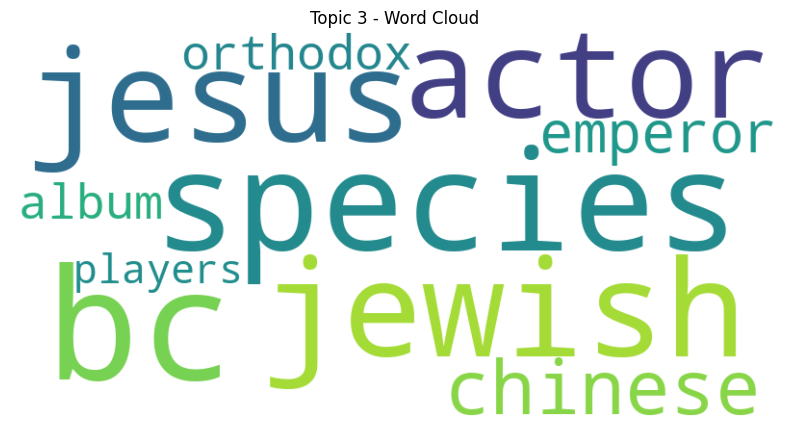

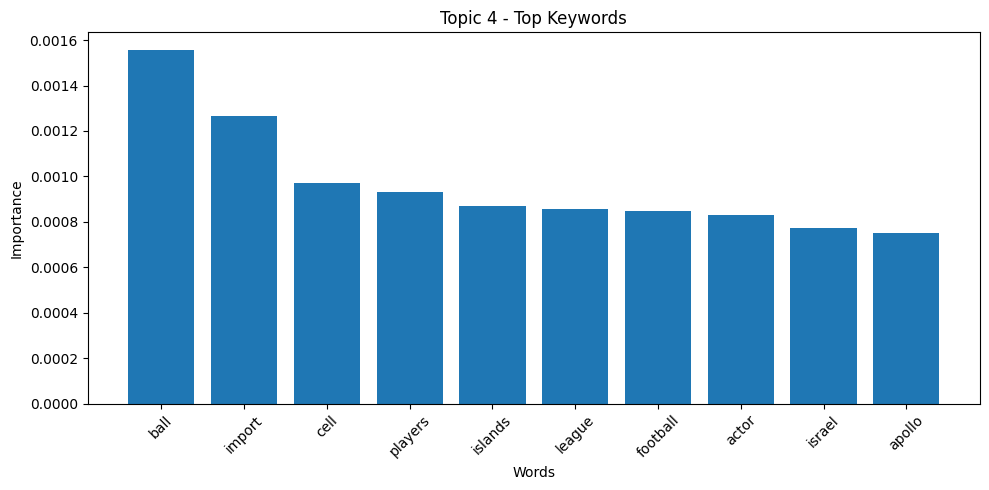

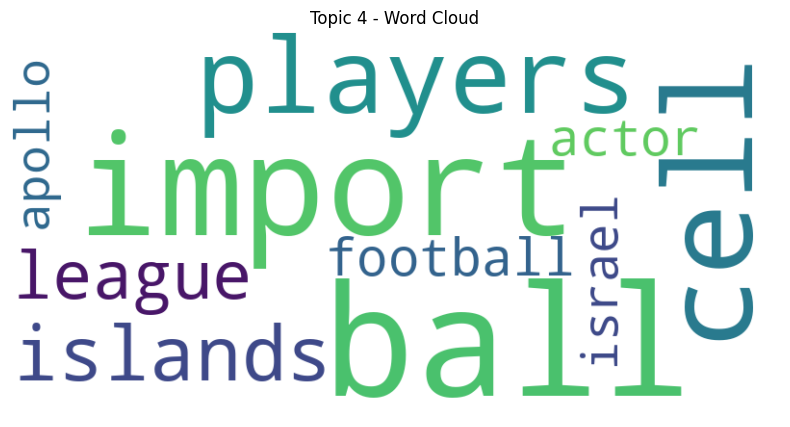

In [12]:
def plot_topic_bars(topic_id, terms):
    words = [w for w, _ in terms]
    scores = [s for _, s in terms]

    plt.figure(figsize=(10, 5))
    plt.bar(words, scores)
    plt.title(f"Topic {topic_id} - Top Keywords")
    plt.xlabel("Words")
    plt.ylabel("Importance")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

def show_topic_wordcloud(topic_id, terms):
    freq_dict = {w: s for w, s in terms}
    wc = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(freq_dict)

    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis("off")
    plt.title(f"Topic {topic_id} - Word Cloud")
    plt.show()

for topic_id, terms in topic_data:
    plot_topic_bars(topic_id, terms)
    show_topic_wordcloud(topic_id, terms)

### Brief Explanation of Topics

- **Topic 0:** This topic seems related to technology, media, and general knowledge because it includes words such as software, apple, album, films, and species.  
- **Topic 1:** This topic appears to combine geography, sports, and economy, with words like chinese, season, league, football, economy, and islands.  
- **Topic 2:** This topic looks associated with history, politics, and geography because it includes emperor, soviet, economy, finland, constitution, and islands.  
- **Topic 3:** This topic seems connected to religion, history, and culture, as shown by words such as jewish, jesus, orthodox, emperor, and actor.  
- **Topic 4:** This topic appears to mix sports, science, and public topics, with words like ball, cell, players, league, football, israel, and apollo.

# Step 5: Analysis and Reflection

For the same 3 sample words used in Step 2, this section includes:
- the topic each word best fits into
- a brief explanation of why it fits that topic
- the type of similarity captured by the model: **topical**, **syntactic**, or **functional**

In [13]:
# Step 5: Analysis and Reflection

import pandas as pd

reflection_rows = [
    {
        "Word": "science",
        "Best Topic": "Topic 0",
        "Why it fits": "Topic 0 contains knowledge-oriented and technical words such as software, apple, album, films, and species, so science fits this broad academic and informational theme.",
        "Similarity Type Captured": "topical"
    },
    {
        "Word": "human",
        "Best Topic": "Topic 3",
        "Why it fits": "Topic 3 includes words such as jewish, jesus, orthodox, and emperor, which relate to people, identity, religion, and society. The word human fits this broader human and cultural context.",
        "Similarity Type Captured": "functional"
    },
    {
        "Word": "data",
        "Best Topic": "Topic 0",
        "Why it fits": "Topic 0 includes software and other informational terms, making it the closest topic to computation, systems, and data-related concepts.",
        "Similarity Type Captured": "functional"
    }
]

reflection_df = pd.DataFrame(reflection_rows)
reflection_df

,Word,Best Topic,Why it fits,Similarity Type Captured
0,science,Topic 0,Topic 0 contains knowledge-oriented and techni...,topical
1,human,Topic 3,"Topic 3 includes words such as jewish, jesus, ...",functional
2,data,Topic 0,Topic 0 includes software and other informatio...,functional


# Final Conclusion

This notebook successfully completed all required tasks of the assignment. It included dataset loading and preprocessing, training of both CBOW and Skip-Gram Word2Vec models, similar-word comparison for selected words, 2D embedding visualization, LDA-based topic modeling, and final analysis and reflection for the sample words.

Overall, the notebook demonstrates how word embeddings and topic modeling can be applied to explore semantic relationships and thematic structure in a text corpus. The results show that CBOW and Skip-Gram capture slightly different types of relationships, while LDA helps identify broader themes present in the data.